In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta
import statsmodels.api as sm

# ------------------------------
# SETTINGS (edit these as needed)
# ------------------------------
CSV_PATH     = "SPY.csv"
TICKER       = "SPY"
RV_COL       = "RV_daily"         # after your renaming
HAR_WINDOWS  = [1, 5, 22]         # classic HAR; change to your candidate set if desired
TRAIN_YEARS  = 4                  # initial training length
EPS_POSITIVE = 1e-12              # for log safety / positivity
SAVE_SPLIT_METRICS = True         # also write per-month metrics to CSV

In [33]:
# ------------------------------
# 1) DATA LOADING & PREP
# ------------------------------
def load_rv_dataframe(csv_path: str, rv_col: str = "RV_daily") -> pd.DataFrame:
    """
    Loads & cleans the RV data exactly like your snippet, keeping only QMLE-Trade.
    Ensures datetime index named 'date' in ascending order.
    """
    rv = pd.read_csv(csv_path)
    rv = rv[["Date", "Volatility", "Type"]].copy()
    rv.rename(columns={"Volatility": rv_col}, inplace=True)
    rv = rv[rv["Type"] == "QMLE-Trade"].copy()
    rv.drop(columns=["Type"], inplace=True)
    rv = rv.set_index("Date")
    rv.index = pd.to_datetime(rv.index)
    rv.index.name = "date"
    rv.sort_index(inplace=True)
    # keep positive RV only (required for logs and QLIKE)
    rv = rv[pd.to_numeric(rv[rv_col], errors="coerce") > 0].copy()
    rv[rv_col] = rv[rv_col].astype(float)
    return rv


In [34]:
# ------------------------------
# 2) FEATURE CONSTRUCTION (HAR)
# ------------------------------
def make_har_features(df: pd.DataFrame, rv_col: str, windows: list[int]) -> pd.DataFrame:
    """
    Builds HAR features: for each window k, use the average of the last k days up to t-1.
    Target is log(RV_t). Features are log of lagged averages.
    """
    out = df.copy()
    # base realized volatility series
    y_level = out[rv_col].copy()

    # compute lagged rolling means up to t-1
    for k in windows:
        # mean of previous k days (exclude t) → shift(1)
        out[f"har_{k}"] = y_level.shift(1).rolling(k, min_periods=k).mean()

    # drop rows where any feature is NaN
    feat_cols = [f"har_{k}" for k in windows]
    out = out.dropna(subset=feat_cols).copy()

    # log-transform: target and features
    out["y_log"] = np.log(out[rv_col].clip(lower=EPS_POSITIVE))
    for k in windows:
        out[f"xlog_{k}"] = np.log(out[f"har_{k}"].clip(lower=EPS_POSITIVE))

    X_cols = [f"xlog_{k}" for k in windows]
    return out, X_cols

In [35]:
# ------------------------------
# 3) METRICS
# ------------------------------
def mse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean((y_true - y_pred) ** 2))

def qlike(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    QLIKE on levels (variance-style). Works for positive y and positive forecasts.
    L = y/f - log(y/f) - 1
    """
    y = np.clip(np.asarray(y_true, dtype=float), EPS_POSITIVE, None)
    f = np.clip(np.asarray(y_pred, dtype=float), EPS_POSITIVE, None)
    return float(np.mean(y / f - np.log(y / f) - 1.0))

In [36]:
# ------------------------------
# 4) SPLITTING: EXPANDING 4y → 1m
# ------------------------------
def month_periods_present(idx: pd.DatetimeIndex) -> pd.PeriodIndex:
    """Unique months that actually exist in the data."""
    return idx.to_period("M").unique().sort_values()

def initial_test_month(first_date: pd.Timestamp, train_years: int) -> pd.Period:
    """First test month starts exactly train_years after the first date (calendar-based)."""
    start = first_date + relativedelta(years=train_years)
    return start.to_period("M")

In [37]:
# ------------------------------
# 5) FIT & FORECAST (OLS on log-RV)
# ------------------------------
def fit_ols_and_predict(X_train: pd.DataFrame, ylog_train: pd.Series,
                        X_test: pd.DataFrame) -> tuple[np.ndarray, np.ndarray]:
    """
    Fit OLS on log(RV). Return (train_pred_levels, test_pred_levels).
    """
    Xtr = sm.add_constant(X_train, has_constant="add")
    Xte = sm.add_constant(X_test,  has_constant="add")
    model = sm.OLS(ylog_train.values, Xtr.values, missing="drop")
    res = model.fit()

    # predictions in log-space
    yhat_log_tr = res.predict(Xtr.values)
    yhat_log_te = res.predict(Xte.values)

    # back to level RV (strictly positive)
    yhat_tr = np.exp(yhat_log_tr)
    yhat_te = np.exp(yhat_log_te)
    return yhat_tr, yhat_te

In [38]:
# ------------------------------
# 6) MAIN EXPANDING-WINDOW LOOP
# ------------------------------
def expanding_har_forecast(df_features: pd.DataFrame,
                           X_cols: list[str],
                           rv_col: str,
                           train_years: int = 4,
                           ticker: str = "SPY") -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Walk forward by months:
      - Train on all data strictly before the current test month (expanding; first train is 4y)
      - Test on the entire current month.
    Returns:
      oos_forecasts: DataFrame[ticker, date, real_RV, pred_RV] for all OOS dates
      split_metrics: per-month insample & OOS metrics
    """
    periods = month_periods_present(df_features.index)
    first = df_features.index.min()
    start_test_per = initial_test_month(first, train_years)

    # keep only months at/after first test month
    test_months = [p for p in periods if p >= start_test_per]
    oos_rows = []
    split_rows = []

    for p in test_months:
        # define train/test masks
        test_mask = (df_features.index.to_period("M") == p)
        test_dates = df_features.index[test_mask]
        if test_dates.empty:
            continue

        test_start = test_dates.min()
        # expanding train: everything strictly before test_start
        train_mask = (df_features.index < test_start)
        X_train = df_features.loc[train_mask, X_cols]
        ylog_train = df_features.loc[train_mask, "y_log"]
        y_train_level = df_features.loc[train_mask, rv_col]

        X_test = df_features.loc[test_mask, X_cols]
        y_test_level = df_features.loc[test_mask, rv_col]

        # ensure first training block is at least train_years long (calendar)
        min_train_end = test_start - relativedelta(years=train_years)
        have_enough_calendar = (X_train.index.min() is not None) and (X_train.index.min() <= min_train_end)
        if (X_train.shape[0] < 30) or (not have_enough_calendar):
            # not enough to fit; skip early incomplete months
            continue

        # fit & predict
        yhat_train, yhat_test = fit_ols_and_predict(X_train, ylog_train, X_test)

        # metrics (levels)
        ins_mse = mse(y_train_level.values, yhat_train)
        ins_qlk = qlike(y_train_level.values, yhat_train)
        oos_mse = mse(y_test_level.values, yhat_test)
        oos_qlk = qlike(y_test_level.values, yhat_test)

        split_rows.append({
            "test_month": str(p),
            "n_train": int(X_train.shape[0]),
            "n_test": int(X_test.shape[0]),
            "MSE_in": ins_mse,
            "QLIKE_in": ins_qlk,
            "MSE_oos": oos_mse,
            "QLIKE_oos": oos_qlk
        })

        # stash OOS rows for this month
        tmp = pd.DataFrame({
            "ticker": ticker,
            "date": X_test.index,
            "real_RV": y_test_level.values,
            "pred_RV": yhat_test
        })
        oos_rows.append(tmp)

    oos_forecasts = pd.concat(oos_rows, axis=0).sort_values("date").reset_index(drop=True)
    split_metrics = pd.DataFrame(split_rows)

    return oos_forecasts, split_metrics

[Saved] SPY_HAR_forecast.csv with 6251 OOS rows

=== Per-month train/test metrics (first 10 rows) ===
test_month  n_train  n_test   MSE_in  QLIKE_in  MSE_oos  QLIKE_oos
   2000-03     1028      23 0.003949  0.092239 0.002948   0.035479
   2000-04     1051      19 0.003919  0.090944 0.018032   0.096160
   2000-05     1070      22 0.004161  0.091177 0.003169   0.035547
   2000-06     1092      22 0.004142  0.090007 0.000785   0.016900
   2000-07     1114      20 0.004080  0.088598 0.001045   0.026222
   2000-08     1134      23 0.004024  0.087500 0.000383   0.015737
   2000-09     1157      20 0.003955  0.086252 0.001096   0.030579
   2000-10     1177      22 0.003899  0.085036 0.007464   0.066175
   2000-11     1199      21 0.003955  0.084586 0.003191   0.039466
   2000-12     1220      20 0.003937  0.083823 0.004096   0.047074

=== Overall OOS metrics (all months combined) ===
OOS MSE   : 0.001590
OOS QLIKE : 0.029232
[Saved] SPY_HAR_split_metrics.csv


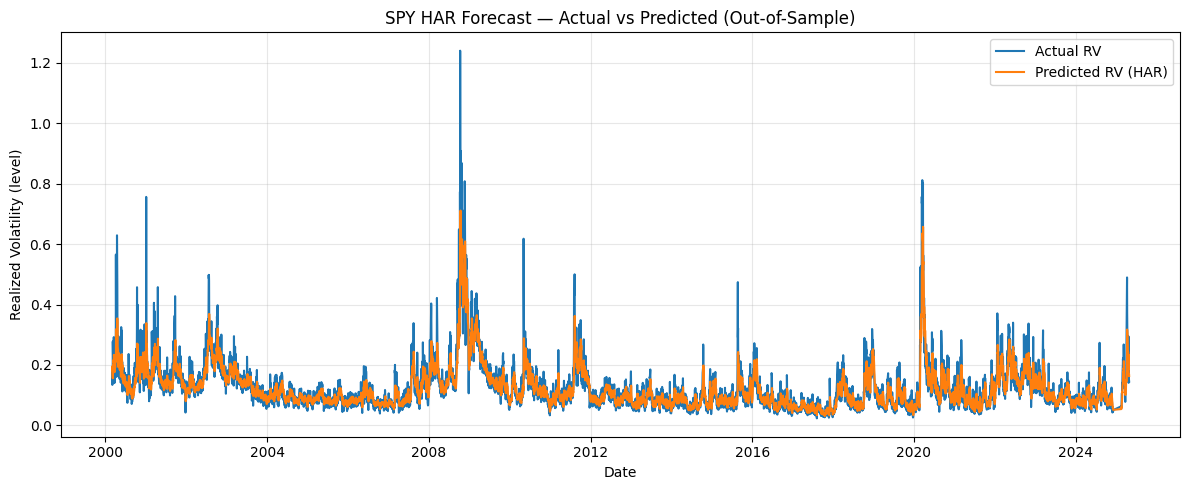

In [39]:
# ------------------------------
# 7) DRIVER
# ------------------------------
def main():
    # Load & prep
    rv = load_rv_dataframe(CSV_PATH, RV_COL)

    # Build HAR features
    feats, X_cols = make_har_features(rv, RV_COL, HAR_WINDOWS)

    # Run expanding-window HAR
    oos_fcst, split_metrics = expanding_har_forecast(
        df_features=feats,
        X_cols=X_cols,
        rv_col=RV_COL,
        train_years=TRAIN_YEARS,
        ticker=TICKER
    )

    # Save forecasts CSV: ticker, date, real RV, predicted RV
    out_name = f"{TICKER}_HAR_forecast.csv"
    oos_fcst.to_csv(out_name, index=False)
    print(f"[Saved] {out_name} with {len(oos_fcst)} OOS rows")

    # Print & optionally save per-month metrics
    if not split_metrics.empty:
        # overall OOS metrics across all months
        overall_mse = mse(oos_fcst["real_RV"].values, oos_fcst["pred_RV"].values)
        overall_qlk = qlike(oos_fcst["real_RV"].values, oos_fcst["pred_RV"].values)
        print("\n=== Per-month train/test metrics (first 10 rows) ===")
        print(split_metrics.head(10).to_string(index=False))

        print("\n=== Overall OOS metrics (all months combined) ===")
        print(f"OOS MSE   : {overall_mse:,.6f}")
        print(f"OOS QLIKE : {overall_qlk:,.6f}")

        if SAVE_SPLIT_METRICS:
            split_name = f"{TICKER}_HAR_split_metrics.csv"
            split_metrics.to_csv(split_name, index=False)
            print(f"[Saved] {split_name}")
    else:
        print("No split metrics produced (check training length vs data).")

    # Plot Actual vs Predicted (OOS)
    if not oos_fcst.empty:
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(oos_fcst["date"], oos_fcst["real_RV"], label="Actual RV")
        ax.plot(oos_fcst["date"], oos_fcst["pred_RV"], label="Predicted RV (HAR)")
        ax.set_title(f"{TICKER} HAR Forecast — Actual vs Predicted (Out-of-Sample)")
        ax.set_xlabel("Date")
        ax.set_ylabel("Realized Volatility (level)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    main()